# Philippine Educational Attainment Analysis

**A regional analysis using Philippine Statistics Authority data**

This portfolio project examines differences in educational attainment across Philippine regions. It is written as a reproducible, beginner-friendly report for readers who want to understand the conclusions without tracing every line of Python.

> **Scope note:** The source notebook also contains exploratory education-and-income work. That working code and its visualizations are retained in a clearly labeled supplementary section, but they are not used to claim changes in educational attainment over time.


## 1. Introduction

### Background

Educational attainment is an important indicator of access to learning opportunities and the development of human capital. Regional comparisons can reveal where attainment is relatively high or low and help frame more focused questions for policy and further research.

### Problem Statement

National summaries can hide substantial differences among regions. This analysis organizes the available PSA data into comparable regional indicators and identifies patterns in the share of the population with college education or higher.

### Objectives

- Prepare a reproducible regional dataset from the PSA workbook stored in Google Drive.
- assess data quality without changing source values.
- compare educational attainment across regions.
- identify the regions with the highest and lowest measured attainment.
- determine whether the available data can support conclusions about change over time.

### Research Questions

1. Which regions have the highest educational attainment?
2. Which regions have the lowest educational attainment?
3. How does educational attainment vary across regions?
4. Has educational attainment improved over time?
5. Which regions improved the most?


## 2. Data Source

### Dataset Information

The analysis uses Philippine Statistics Authority workbooks stored in the notebook owner's Google Drive:

- `3_HGC and Literacy Statistical Table.xlsx`, worksheet `Table B`
- `Table 1a. CV_2018, 2021 and 2023p Average Annual Family Income, by Per Capita Income Decile Class and by Region, Province and HUCs.xlsx`, worksheet `Table 1a`

The education indicator is calculated from the counts extracted by the original notebook:

`college_pct = (college + post_bac) / total * 100`

### Variables

| Variable | Description |
|---|---|
| `region_raw` | Region label as written in the education workbook |
| `region_clean` | Standardized region label used for matching |
| `college_pct` | Percentage represented by college plus post-baccalaureate counts divided by the extracted total |
| `income_2018`, `income_2021`, `income_2023` | Fields retained from the original supplementary extraction |

### Limitations

- The education data provide one comparable snapshot, identified in the original chart as 2020. They cannot establish improvement over time.
- The indicator is an operational measure created by the notebook and should be interpreted according to the workbook's population universe and category definitions.
- The education-to-income merge contains 17 matched regions. NIR appears only in the income extraction, while NCR has missing extracted income values.
- The income filename includes `CV`; the supplementary fields must be checked against the workbook header before they are described as monetary income. Their original names and code are retained for reproducibility, not treated as validated education findings.
- Workbook row and column locations are hard-coded, so a revised PSA file layout could require updates.


## 3. Import Libraries

The notebook uses pandas for tabular analysis, Matplotlib and Seaborn for visualization, and the existing `openpyxl` workbook reader. `os` is used only to locate the Google Drive file.


In [ ]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 4. Load Dataset

### Google Drive Connection

Mount Google Drive so Colab can access the source workbooks. The source files remain in Drive; no local replacement is introduced.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


### Data Loading

The following search confirms the education workbook path. The next cell preserves the original extraction logic, standardizes region names, extracts the supplementary fields, and performs the regional merge.


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if '3_HGC' in f:
            print(os.path.join(root, f))


In [23]:
# ---- Education: Table B ----
wb = openpyxl.load_workbook("/content/drive/MyDrive/3_HGC and Literacy Statistical Table.xlsx", data_only=True)
ws = wb["Table B"]

edu_rows = []
for r in range(1, ws.max_row):
    region_name = ws.cell(row=r, column=1).value
    next_row_label = ws.cell(row=r + 1, column=1).value
    if next_row_label == "Both Sexes" and region_name != "PHILIPPINES":
        total = ws.cell(row=r + 2, column=2).value
        college = ws.cell(row=r + 33, column=2).value
        post_bac = ws.cell(row=r + 36, column=2).value
        college_pct = (college + post_bac) / total * 100
        edu_rows.append((region_name, college_pct))

education = pd.DataFrame(edu_rows, columns=["region_raw", "college_pct"])

EDU_NAME_MAP = {
    "NATIONAL CAPITAL REGION": "NCR",
    "CORDILLERA ADMINISTRATIVE REGION (CAR)": "CAR",
    "REGION I (ILOCOS REGION)": "REGION I",
    "REGION II (CAGAYAN VALLEY)": "REGION II",
    "REGION III (CENTRAL LUZON)": "REGION III",
    "REGION IV-A (CALABARZON)": "REGION IV-A",
    "MIMAROPA REGION": "MIMAROPA",
    "REGION V (BICOL REGION)": "REGION V",
    "REGION VI (WESTERN VISAYAS)": "REGION VI",
    "REGION VII (CENTRAL VISAYAS)": "REGION VII",
    "REGION VIII (EASTERN VISAYAS)": "REGION VIII",
    "REGION IX (ZAMBOANGA PENINSULA)": "REGION IX",
    "REGION X (NORTHERN MINDANAO)": "REGION X",
    "REGION XI (DAVAO REGION)": "REGION XI",
    "REGION XII (SOCCSKSARGEN)": "REGION XII",
    "REGION XIII (Caraga)": "CARAGA",
    "BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO (BARMM)": "BARMM",
}
education["region_clean"] = education["region_raw"].map(EDU_NAME_MAP)

# ---- Income: Table 1 ----
wb2 = openpyxl.load_workbook(
    "/content/drive/MyDrive/Table 1a. CV_2018, 2021 and 2023p Average Annual Family Income, by Per Capita Income Decile Class and by Region, Province and HUCs.xlsx",
    data_only=True,
)
ws2 = wb2["Table 1a"]

INCOME_REGIONS = [
    (8, "NCR"), (31, "CAR"), (40, "REGION I"), (46, "REGION II"), (53, "REGION III"),
    (64, "REGION IV-A"), (72, "MIMAROPA"), (80, "REGION V"), (88, "REGION VI"),
    (96, "NIR"), (102, "REGION VII"), (109, "REGION VIII"), (118, "REGION IX"),
    (125, "REGION X"), (134, "REGION XI"), (142, "REGION XII"), (149, "CARAGA"), (157, "BARMM"),
]

inc_rows = []
for row_num, code in INCOME_REGIONS:
    income_2018 = ws2.cell(row=row_num, column=2).value
    income_2021 = ws2.cell(row=row_num, column=13).value
    income_2023 = ws2.cell(row=row_num, column=24).value
    inc_rows.append((code, income_2018, income_2021, income_2023))

income = pd.DataFrame(inc_rows, columns=["region_clean", "income_2018", "income_2021", "income_2023"])

# ---- Merge ----
df = education.merge(income, on="region_clean", how="inner")
print(df.shape)
print(df)


(17, 6)
                                           region_raw  college_pct  \
0                             NATIONAL CAPITAL REGION    35.523572   
1              CORDILLERA ADMINISTRATIVE REGION (CAR)    29.336520   
2                            REGION I (ILOCOS REGION)    23.471567   
3                          REGION II (CAGAYAN VALLEY)    23.848653   
4                          REGION III (CENTRAL LUZON)    23.130215   
5                            REGION IV-A (CALABARZON)    26.728624   
6                                     MIMAROPA REGION    18.248427   
7                             REGION V (BICOL REGION)    17.934593   
8                         REGION VI (WESTERN VISAYAS)    22.869556   
9                        REGION VII (CENTRAL VISAYAS)    23.013999   
10                      REGION VIII (EASTERN VISAYAS)    19.527524   
11                    REGION IX (ZAMBOANGA PENINSULA)    20.630070   
12                       REGION X (NORTHERN MINDANAO)    20.967441   
13          

## 5. Data Understanding

### Dataset Overview

The merged dataset has 17 regional records and six columns. Each row represents a region matched between the education and supplementary tables.

### Initial Inspection

The following cells inspect the structure, data types, sample records, and descriptive statistics. They do not modify the dataset.


In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


In [ ]:
df.info()
display(df.describe(include="all").T)


### Initial Observations

- The analysis contains one record per matched region.
- `college_pct` is the primary measure for answering the education research questions.
- The education values span approximately **13.57% to 35.52%** in the saved run.
- The supplementary NCR fields are missing, which pandas excludes automatically from pairwise correlation calculations.


## 6. Data Cleaning

The checks below audit the data without changing source values or analytical results.

### Missing Values


In [ ]:
missing_values = df.isna().sum().to_frame("missing_count")
missing_values["missing_percent"] = (missing_values["missing_count"] / len(df) * 100).round(2)
display(missing_values)


### Duplicate Records


In [ ]:
duplicate_records = df.duplicated().sum()
duplicate_regions = df["region_clean"].duplicated().sum()
print("Duplicate rows:", duplicate_records)
print("Duplicate standardized region labels:", duplicate_regions)


### Data Consistency Checks


In [ ]:
print("Unmapped education region labels:", education["region_clean"].isna().sum())
print("College percentages within 0-100:", df["college_pct"].between(0, 100).all())
print("Matched regions:", df["region_clean"].nunique())
print("Education-only regions:", sorted(set(education["region_clean"]) - set(income["region_clean"])))
print("Supplementary-only regions:", sorted(set(income["region_clean"]) - set(education["region_clean"])))


### Cleaning Summary

The workflow standardizes regional labels and merges the two tables without altering values. The saved output shows 17 matched regions. Missing supplementary values are retained rather than imputed, and the checks make duplicate, range, and matching issues visible to the reader.


## 7. Exploratory Data Analysis

### Distribution Analysis

**Purpose:** Show the overall shape and concentration of regional educational-attainment percentages before ranking individual regions.


In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df["college_pct"], bins=8, kde=True)
plt.xlabel("Population with college education or higher (%)")
plt.ylabel("Number of regions")
plt.title("Distribution of College-Level Educational Attainment by Region")
plt.tight_layout()
plt.show()


**Observation:** In the saved data, the regional mean is about **22.23%** and the median is about **20.97%**. Most values are closer to the low twenties, while a small number of regions extend into the upper twenties and thirties.

**Interpretation:** Educational attainment is not evenly distributed across regions. The higher values pull the mean above the median, suggesting a right-skewed distribution.

### Regional Comparison

The complete ordered regional comparison is presented under Research Question 3 to avoid repeating the same chart.

### Supplementary Analysis Retained from the Original Notebook

The next two analyses preserve the original education-and-income exploration. They provide context only and do not answer the five educational-attainment research questions.

#### Education and 2021 Supplementary Field

**Purpose:** Preserve the original test of association between `college_pct` and the field named `income_2021` in the notebook.


Correlation: 0.177
Correlation without NCR: 0.177


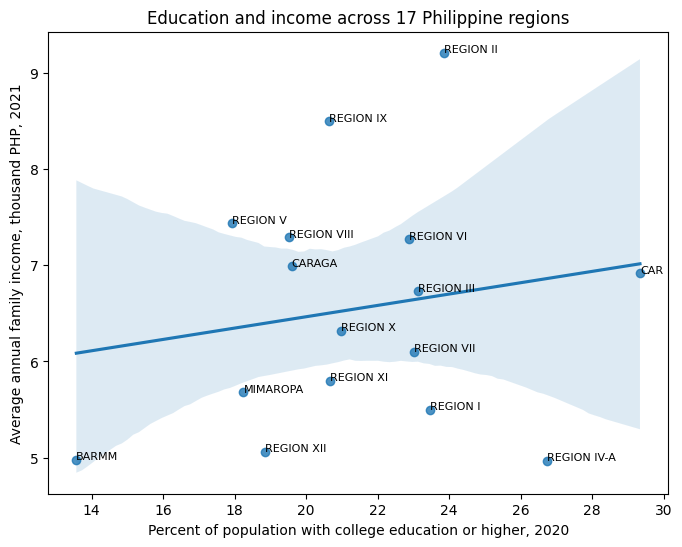

In [24]:
correlation = df["college_pct"].corr(df["income_2021"])
print("Correlation:", round(correlation, 3))

df_no_ncr = df[df.region_clean != "NCR"]
correlation_no_ncr = df_no_ncr["college_pct"].corr(df_no_ncr["income_2021"])
print("Correlation without NCR:", round(correlation_no_ncr, 3))

plt.figure(figsize=(8, 6))
sns.regplot(x="college_pct", y="income_2021", data=df)
for _, row in df.iterrows():
    plt.annotate(row["region_clean"], (row["college_pct"], row["income_2021"]), fontsize=8)
plt.xlabel("Percent of population with college education or higher, 2020")
plt.ylabel("Average annual family income, thousand PHP, 2021")
plt.title("Education and income across 17 Philippine regions")
plt.show()


**Observation:** The saved run reports a correlation of **0.177**. The result is unchanged after explicitly removing NCR because NCR already has a missing value and is excluded from the pairwise calculation.

**Interpretation:** The retained calculation shows a weak positive linear association in this small regional sample. It should not be interpreted causally, and the supplementary field must first be verified against the source header because the filename indicates coefficient-of-variation (`CV`) data.

#### Supplementary Regional Trend

**Purpose:** Preserve the original comparison of the regions selected as the top and bottom five based on the 2021 supplementary field across 2018, 2021, and 2023.


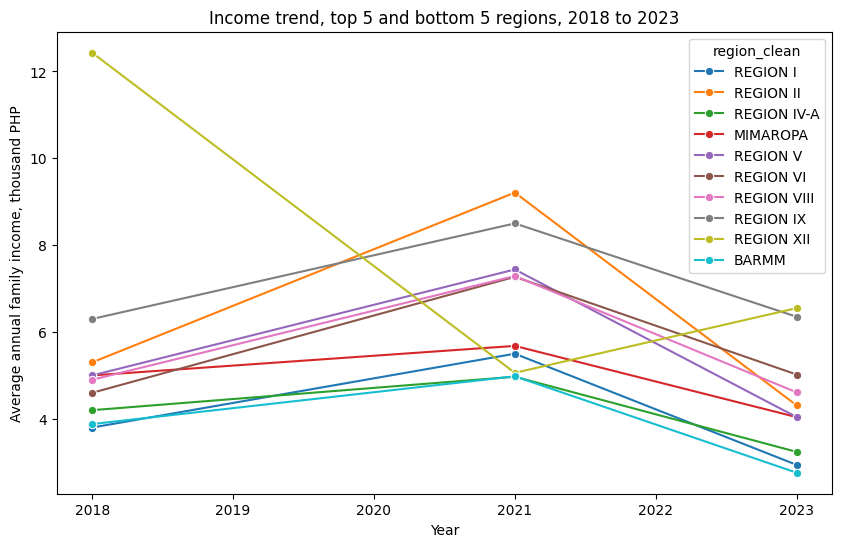

In [25]:
income_long = income.melt(
    id_vars="region_clean",
    value_vars=["income_2018", "income_2021", "income_2023"],
    var_name="year", value_name="income",
)
income_long["year"] = income_long["year"].str.extract(r"(\d+)").astype(int)
income_long = income_long[income_long.region_clean != "NIR"]  # drop the row education can't match, for a consistent region set

top5 = df.nlargest(5, "income_2021")["region_clean"].tolist()
bottom5 = df.nsmallest(5, "income_2021")["region_clean"].tolist()
income_long_subset = income_long[income_long.region_clean.isin(top5 + bottom5)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=income_long_subset, x="year", y="income", hue="region_clean", marker="o")
plt.xlabel("Year")
plt.ylabel("Average annual family income, thousand PHP")
plt.title("Income trend, top 5 and bottom 5 regions, 2018 to 2023")
plt.show()


**Observation:** The plotted series change across the three available years and differ among the selected regions.

**Interpretation:** This chart describes only the retained supplementary fields. It does **not** demonstrate change in educational attainment, because `college_pct` has no comparable time series in the notebook.

### Summary of Findings

- Regional college-level attainment varies materially in the available snapshot.
- A few regions sit well above the center of the distribution.
- The supplementary analysis is exploratory and requires source-label verification before substantive income interpretation.


## 8. Research Question 1

### Which regions have the highest educational attainment?

#### Analysis

Rank regions by `college_pct` in descending order and display the top five.


In [ ]:
highest_attainment = (
    df[["region_clean", "college_pct"]]
    .nlargest(5, "college_pct")
    .assign(college_pct=lambda x: x["college_pct"].round(2))
)
display(highest_attainment)


#### Results

The saved analysis ranks **NCR (35.52%)**, **CAR (29.34%)**, **Region IV-A (26.73%)**, **Region II (23.85%)**, and **Region I (23.47%)** as the five highest regions.

#### Interpretation

NCR leads the measured indicator, with CAR and Region IV-A also standing above the overall regional average. These rankings are descriptive and do not by themselves explain why the differences exist.


## 9. Research Question 2

### Which regions have the lowest educational attainment?

#### Analysis

Rank regions by `college_pct` in ascending order and display the bottom five.


In [ ]:
lowest_attainment = (
    df[["region_clean", "college_pct"]]
    .nsmallest(5, "college_pct")
    .assign(college_pct=lambda x: x["college_pct"].round(2))
)
display(lowest_attainment)


#### Results

The saved analysis ranks **BARMM (13.57%)**, **Region V (17.93%)**, **MIMAROPA (18.25%)**, **Region XII (18.84%)**, and **Region VIII (19.53%)** as the five lowest regions.

#### Interpretation

These regions have the smallest shares under the notebook's operational definition. The result identifies where further investigation may be valuable; it should not be treated as evidence of causes or individual educational outcomes.


## 10. Research Question 3

### How does educational attainment vary across regions?

#### Analysis

**Purpose:** Compare all matched regions on one consistent scale and show the size of the regional gap.


In [ ]:
attainment_by_region = df.sort_values("college_pct", ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=attainment_by_region, x="college_pct", y="region_clean", color="#4C78A8")
plt.xlabel("Population with college education or higher (%)")
plt.ylabel("Region")
plt.title("College-Level Educational Attainment Across Philippine Regions")
plt.tight_layout()
plt.show()

regional_range = df["college_pct"].max() - df["college_pct"].min()
print("Regional range (percentage points):", round(regional_range, 2))


#### Results

**Observation:** The saved data range from **13.57% in BARMM** to **35.52% in NCR**, a difference of approximately **21.95 percentage points**.

#### Interpretation

The chart shows substantial regional variation rather than a uniform national pattern. The gap between the highest and lowest values is large relative to the mean of about 22.23%, making region an important dimension for descriptive reporting and follow-up analysis.


## 11. Research Question 4

### Has educational attainment improved over time?

#### Analysis

The available columns were reviewed for repeated education measurements. Only one comparable educational-attainment indicator, `college_pct`, is present.

#### Results

This research question **cannot be answered with the current notebook data**. The 2018, 2021, and 2023 fields belong to the supplementary workbook and are not educational-attainment measurements.

#### Interpretation

Inferring an education trend from those fields would mix different concepts and produce an unsupported conclusion. At least two consistently defined education observations are required to evaluate improvement.


## 12. Research Question 5

### Which regions improved the most?

#### Analysis

Regional improvement requires calculating the change between comparable educational-attainment years for every region. Those repeated education values are not available in the current dataset.

#### Results

No defensible regional improvement ranking can be produced from this notebook.

#### Interpretation

Leaving the ranking unanswered is preferable to substituting the supplementary fields or fabricating a time dimension. This question should be revisited after adding another PSA education table with matching definitions and regional coverage.


## 13. Discussion

### Major Findings

- NCR, CAR, and Region IV-A lead the available regional education indicator.
- BARMM records the lowest value, followed by Region V and MIMAROPA.
- The approximately 21.95-percentage-point regional range indicates substantial variation.
- The current data support cross-sectional comparison, not change-over-time conclusions.

### Implications

The results provide a clear starting point for identifying regional disparities and prioritizing deeper investigation. They do not establish the causes of those disparities. Population structure, access to institutions, migration, urbanization, and socioeconomic conditions would require additional data and careful analysis.


## 14. Conclusion

### Summary

This project transformed the available PSA workbook data into a reproducible regional comparison of college-level educational attainment. It documented the extraction, matching, quality checks, ranking, and limits of the evidence.

### Answers to Research Questions

1. **Highest:** NCR, CAR, Region IV-A, Region II, and Region I.
2. **Lowest:** BARMM, Region V, MIMAROPA, Region XII, and Region VIII.
3. **Variation:** Values span about 21.95 percentage points, from 13.57% to 35.52%.
4. **Improvement over time:** Not answerable from one education snapshot.
5. **Most improved:** Not answerable without comparable regional education years.

### Final Takeaway

The available data reveal meaningful regional differences in educational attainment, while also showing why conclusions must stay within the limits of the dataset. A professional analysis is strongest when it reports both what the evidence shows and what it cannot yet support.


## 15. Recommendations

- Use the lower-ranked regions as starting points for deeper, context-aware investigation rather than treating rank alone as a policy diagnosis.
- Validate the population universe and category labels in `Table B` before external publication.
- Verify the supplementary worksheet headers, especially the meaning of `CV`, before presenting those values as income.
- Pair regional attainment results with relevant access, demographic, and socioeconomic indicators in future descriptive work.


## 16. Future Work

- Add comparable PSA educational-attainment tables for multiple years.
- Harmonize regional boundaries across years, especially where regional classifications change.
- Calculate absolute and percentage-point changes only after confirming consistent definitions.
- Extend the analysis to sex, age group, or urban-rural classifications when supported by the source tables.
- Add a data dictionary containing exact PSA table labels, units, reference periods, and source links.


## 17. References

- Philippine Statistics Authority. *3_HGC and Literacy Statistical Table.xlsx*, `Table B`.
- Philippine Statistics Authority. *Table 1a. CV_2018, 2021 and 2023p Average Annual Family Income, by Per Capita Income Decile Class and by Region, Province and HUCs.xlsx*, `Table 1a`.
- Source files accessed through the project owner's Google Drive in Google Colab.

> Before publishing, add the official PSA download-page URLs and access date associated with the exact workbook versions in Google Drive.
